# T011 · 在线 API 网络服务查询

**注：** 本教程是 TeachOpenCADD 的一部分。TeachOpenCADD 是一个旨在教授领域专用技能，并提供可作为研究项目起点的流程模板的平台。

作者：

- Jaime Rodríguez-Guerra, 2019-2020, [Volkamer 实验室](https://volkamerlab.org/)
- Dominique Sydow, 2019-2020, [Volkamer 实验室](https://volkamerlab.org/)
- Talia B. Kimber, 2021, [Volkamer 实验室](https://volkamerlab.org/)


## 本教程的目标

在本 notebook 中，你将学习如何在药物设计的背景下，通过 Python 编程方式使用在线网络服务。在本教程结束时，你将熟悉 REST 服务和网页抓取。


### 理论部分内容

* 从服务器端视角看数据访问


### 实践部分内容

* 下载静态文件
* 访问动态生成的内容
* 编程接口
* 文档解析
* 浏览器远程控制


### 参考文献

本指南非常注重实践，为了清晰起见省略了一些技术定义。不过，为了完全理解幕后发生的事情，你还需要掌握一些基本术语。

* [客户端-服务器模型](https://en.wikipedia.org/wiki/Client%E2%80%93server_model)
* [HTTP 请求](https://en.wikipedia.org/wiki/HTTP_request)
* [HTTP 请求方法](https://developer.mozilla.org/en-US/docs/Web/HTTP/Methods)
* [Web API 接口格式](https://en.wikipedia.org/wiki/Web_API)
* [REST](https://en.wikipedia.org/wiki/Representational_state_transfer)
* [SOAP](https://en.wikipedia.org/wiki/SOAP)
* [HTML](https://en.wikipedia.org/wiki/HTML)
* [Swagger](https://swagger.io/)
* [OpenAPI](https://www.openapis.org/)
* [Selenium WebDriver](https://www.seleniumhq.org/projects/webdriver/)


In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 11
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论


互联网是由多台互联计算机组成的网络，它们相互交换数据。某种程度上，你实际上是通过带有某些参数的请求来向机器（服务器）查询特定数据。这些数据要么是：

- **A**. 直接提供的，因为服务器已经预见到了你的请求并提前计算好了结果。
- **B**. 在你请求之后动态生成的。

通常，后台会运行某种软件来检查你请求的参数，在数据库中搜索符合条件的数据（数据库是一个以表结构组织的信息集合），然后将结果发送回给你。

根据预期用途和数据复杂度的不同，访问 Web API 的方式也有很多种。在本教程中，我们将深入探讨以下技术：

* 下载静态文件
* 访问动态生成的内容
* 访问编程接口
  * HTTP/REST APIs
* 解析文档（网页抓取）
* 浏览器远程控制

我们从最简单的方法开始，逐步深入到最复杂的方法。


## 实践


In [2]:
from pathlib import Path

HERE = Path(_dh[-1])
DATA = HERE / "data"
TMPDATA = DATA / "_tmp"  # 此目录被 git 忽略
TMPDATA.mkdir(parents=True, exist_ok=True)

### 下载静态文件

在这种情况下，网络服务器托管了一些文件，你可以直接下载并立即使用。你只需要向服务器*请求*正确的地址或 _URL_（统一资源定位符）。你在浏览器中一直在做这件事：你输入一个 URL，然后服务器返回一个 HTML 文档。服务器使用的是 _HTTP 协议_，即用于传输此类信息的一组规则。通过 Python，我们可以借助 `requests` 库轻松地发起 HTTP 请求。

让我们从一个简单的例子开始：下载一个包含激酶名称的 CSV 文件。请注意，我们将 URL 存储在了一个变量中，以便于重复使用。

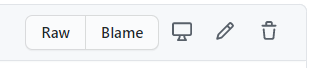

In [3]:
import requests

url = "https://raw.githubusercontent.com/openkinome/kinodata/master/data/KinHubKinaseList.csv"
response = requests.get(url)
response.raise_for_status()
response

# NBVAL_CHECK_OUTPUT

<Response [200]>

当你调用 `requests.get(...)` 时，会获取一个 `Response` 对象。这__不是__你要下载的文件，而是一个封装了 HTTP 查询以及服务器返回给你的 _响应_ 的对象。在检查内容之前，我们总是应该调用 `.raise_for_status()`，以确保没有遇到任何网络错误（被重定向、未找到、服务器错误等）。

在下面的例子中，我们故意使用了一个错误的 URL 来演示 `.raise_for_status()` 会引发异常。


In [4]:
# NBVAL_RAISES_EXCEPTION
bad_url = "https://raw.githubusercontent.com/openkinome/kinodata/master/data/KinHubKinaseList.txt"
bad_response = requests.get(bad_url)
bad_response.raise_for_status()
bad_response

HTTPError: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/openkinome/kinodata/master/data/KinHubKinaseList.txt

好的，现在让我们来获取 CSV 文件的内容！根据你的需求，你需要使用以下属性之一：

* `response.content`：服务器返回的 _bytes_（原始字节数据）。
* `response.text`：将文件内容作为字符串，前提是服务器提供了编码信息。

由于这是一个文本文件，使用 `.text` 更方便。`print` 语句会将其内容打印到 notebook 中。


In [5]:
print(*response.text.splitlines()[:10], sep="\n")

﻿xName,Manning Name,HGNC Name,Kinase Name,Group,Family,SubFamily,UniprotID
ABL1,ABL,ABL1,Tyrosine-protein kinase ABL1,TK,Abl,,P00519
ACK,ACK,TNK2,Activated CDC42 kinase 1,TK,Ack,,Q07912
ACTR2,ACTR2,ACVR2A,Activin receptor type-2A,TKL,STKR,STKR2,P27037
ACTR2B,ACTR2B,ACVR2B,Activin receptor type-2B,TKL,STKR,STKR2,Q13705
ADCK4,ADCK4,ADCK4,Uncharacterized aarF domain-containing protein kinase 4,Atypical,ABC1,ABC1-A,Q96D53
Trb1,Trb1,TRIB1,Tribbles homolog 1,CAMK,Trbl,,Q96RU8
BRSK2,BRSK2,BRSK2,Serine/threonine-protein kinase BRSK2,CAMK,CAMKL,BRSK,Q8IWQ3
Wnk2,Wnk2,WNK2,Serine/threonine-protein kinase WNK2,Other,WNK,,Q9Y3S1
AKT1,AKT1,AKT1,RAC-alpha serine/threonine-protein kinase,AGC,Akt,,P31749


当然，你也可以使用 Python 中常见的文件写入方式将其保存到磁盘。由于我们是在 _下载_ 文件，建议使用原始字节内容，而不是文本版本！这意味着你应该使用 `response.content` 并以字节模式（末尾加上 `b`）打开文件。

另一种下载文件的方法是使用 `urllib.request.urlretrieve`。


In [6]:
with open(TMPDATA / "kinhub.csv", "wb") as f:
    f.write(response.content)

再次打开文件以确认我们写入了内容。


In [7]:
# 需要使用 encoding="utf-8-sig" 确保在所有平台上的编码正确
with open(TMPDATA / "kinhub.csv", encoding="utf-8-sig") as f:
    # Zip 在较短的迭代器结束时会停止迭代
    # 传入 range(5) 使我们只获取五行 ;)
    for _, line in zip(range(5), f):
        print(line.rstrip())

# NBVAL_CHECK_OUTPUT

xName,Manning Name,HGNC Name,Kinase Name,Group,Family,SubFamily,UniprotID
ABL1,ABL,ABL1,Tyrosine-protein kinase ABL1,TK,Abl,,P00519
ACK,ACK,TNK2,Activated CDC42 kinase 1,TK,Ack,,Q07912
ACTR2,ACTR2,ACVR2A,Activin receptor type-2A,TKL,STKR,STKR2,P27037
ACTR2B,ACTR2B,ACVR2B,Activin receptor type-2B,TKL,STKR,STKR2,Q13705


ℹ **提示**：如果你只是想下载一个 CSV 文件并用 Pandas 打开，可以直接将原始 URL 传递给 `pandas.read_csv`。它会帮你下载文件！


In [8]:
import pandas as pd

df = pd.read_csv(
    "https://raw.githubusercontent.com/openkinome/kinodata/master/data/KinHubKinaseList.csv"
)
df.head()
# NBVAL_CHECK_OUTPUT

,xName,Manning Name,HGNC Name,Kinase Name,Group,Family,SubFamily,UniprotID
0,ABL1,ABL,ABL1,Tyrosine-protein kinase ABL1,TK,Abl,NaN,P00519
1,ACK,ACK,TNK2,Activated CDC42 kinase 1,TK,Ack,NaN,Q07912
2,ACTR2,ACTR2,ACVR2A,Activin receptor type-2A,TKL,STKR,STKR2,P27037
3,ACTR2B,ACTR2B,ACVR2B,Activin receptor type-2B,TKL,STKR,STKR2,Q13705
4,ADCK4,ADCK4,ADCK4,Uncharacterized aarF domain-containing protein...,Atypical,ABC1,ABC1-A,Q96D53


关于文件下载有一点需要注意。上述方法会将整个文件下载到内存中，这对于非常大的文件可能会成为问题。如果你打算下载一个非常大的文件，可以使用[流式请求](https://requests.readthedocs.io/en/master/api/#requests.Response.iter_content)直接将其写入磁盘。

不过**提示**，即便是流式请求，也需要在内存中保留文件的自定义块，因此请注意这一点，如果文件真的非常庞大，应该使用 `wget` 等专用工具。


In [9]:
import shutil
from IPython.display import Video

response = requests.get(
    "https://archive.org/download/SlowMotionFlame/slomoflame_512kb.mp4", stream=True
)
response.raise_for_status()

with open(TMPDATA / "video.mp4", "wb") as tmp:
    for chunk in response.iter_content(chunk_size=8192):
        tmp.write(chunk)

    # 让我们在 Jupyter 里播放影片！
    # 传递给小部件的路径需要相对于 notebook，否则会出现 404 :)
    display(Video(Path(tmp.name).relative_to(HERE)))

### 访问动态生成的内容

到目前为止，我们已经能够检索远程服务器上存在的 _文件_。为此，我们使用了 `requests.get` 和指向该文件的 URL。

事实证明，同样的技术也可以用来获取 __动态生成__ 的内容。例如，UniProt 网站会在你请求后才生成对应的网页。让我们看看如果我们从 UniProt 请求一个众所周知的蛋白质会发生什么。

通常，我们会使用 `https://www.uniprot.org/uniprot/P0DTC2` 在浏览器中打开该蛋白质的页面，但在这里，我们请求该页面的文本表示。


In [10]:
r = requests.get("https://www.uniprot.org/uniprot/P0DTC2")
r.raise_for_status()
print(r.text[:5000])

<!doctype html><html lang="en"><head><meta charset="utf-8"/><title>UniProt</title><meta name="viewport" content="width=device-width,initial-scale=1"/><link rel="preconnect" href="https://rest.uniprot.org/"/><link rel="preconnect" href="https://fonts.googleapis.com"/><link rel="preconnect" href="https://fonts.gstatic.com" crossorigin/><meta name="theme-color" content="#00639a"/><meta property="og:logo" content="https://www.uniprot.org/android-chrome-512x512.png"/><meta property="og:title" content="UniProt"/><meta property="og:description" content="UniProt is the world's leading high-quality, comprehensive and freely accessible resource of protein sequence and functional information."/><meta property="og:image" content="https://www.uniprot.org/og-uniprot-wide-logo-1200x630.png"/><meta property="og:type" content="website"/><meta property="og:site_name" content="UniProt"/><meta property="og:image" content="https://www.uniprot.org/og-uniprot-square-logo-1200x1200.png"/><meta property="og:im

哇，这些噪音是什么？你看到的是网页的 HTML 内容！这是网页开发者用来编写网页的标记语言。

有专门的库可以处理 HTML 并提取实际内容（比如 `BeautifulSoup`；稍后会详细介绍），但等一下：UniProt 网站是否提供了某种"文本模式"？让我们仔细看看这个 URL... `uniprot/P0DTC2.txt`！


In [11]:
r = requests.get("https://www.uniprot.org/uniprot/P0DTC2.txt")
r.raise_for_status()
print(r.text[:1000])

ID   SPIKE_SARS2             Reviewed;        1273 AA.
AC   P0DTC2;
DT   22-APR-2020, integrated into UniProtKB/Swiss-Prot.
DT   22-APR-2020, sequence version 1.
DT   18-JUN-2025, entry version 28.
DE   RecName: Full=Spike glycoprotein {ECO:0000255|HAMAP-Rule:MF_04099};
DE            Short=S glycoprotein {ECO:0000255|HAMAP-Rule:MF_04099};
DE   AltName: Full=E2 {ECO:0000255|HAMAP-Rule:MF_04099};
DE   AltName: Full=Peplomer protein {ECO:0000255|HAMAP-Rule:MF_04099};
DE   Contains:
DE     RecName: Full=Spike protein S1 {ECO:0000255|HAMAP-Rule:MF_04099};
DE   Contains:
DE     RecName: Full=Spike protein S2 {ECO:0000255|HAMAP-Rule:MF_04099};
DE   Contains:
DE     RecName: Full=Spike protein S2' {ECO:0000255|HAMAP-Rule:MF_04099};
DE   Flags: Precursor;
GN   Name=S {ECO:0000255|HAMAP-Rule:MF_04099}; ORFNames=2;
OS   Severe acute respiratory syndrome coronavirus 2 (2019-nCoV) (SARS-CoV-2).
OC   Viruses; Riboviria; Orthornavirae; Pisuviricota; Pisoniviricetes;
OC   Nidovirales; Cornidovirineae;

这__正是__我们在浏览器中看到的内容！对于这类场景，纯文本非常方便。不过，蛋白质序列在文件的末尾。要获取它，你需要发挥创意，分析每一行中的小标签。看它是如何以 `SQ   SEQUENCE` 开头的，然后在 `//` 处结束？让我们提取它。


In [12]:
sequence_block = False
lines = []
for line in r.text.splitlines():
    if line.startswith("SQ"):
        sequence_block = True
    elif line.startswith("//"):
        sequence_block = False

    if sequence_block:
        line = line.strip()  # 删除行首和行尾的空格与换行
        line = line.replace(" ", "")  # 删除行中间的空格
        lines.append(line)
sequence = "".join(lines[1:])  # 第一行是元数据头
print(f"This is your sequence: {sequence}")

# NBVAL_CHECK_OUTPUT

This is your sequence: MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSSVLHSTQDLFLPFFSNVTWFHAIHVSGTNGTKRFDNPVLPFNDGVYFASTEKSNIIRGWIFGTTLDSKTQSLLIVNNATNVVIKVCEFQFCNDPFLGVYYHKNNKSWMESEFRVYSSANNCTFEYVSQPFLMDLEGKQGNFKNLREFVFKNIDGYFKIYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLLKYNENGTITDAVDCALDPLSETKCTLKSFTVEKGIYQTSNFRVQPTESIVRFPNITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKSTNLVKNKCVNFNFNGLTGTGVLTESNKKFLPFQQFGRDIADTTDAVRDPQTLEILDITPCSFGGVSVITPGTNTSNQVAVLYQDVNCTEVPVAIHADQLTPTWRVYSTGSNVFQTRAGCLIGAEHVNNSYECDIPIGAGICASYQTQTNSPRRARSVASQSIIAYTMSLGAENSVAYSNNSIAIPTNFTISVTTEILPVSMTKTSVDCTMYICGDSTECSNLLLQYGSFCTQLNRALTGIAVEQDKNTQEVFAQVKQIYKTPPIKDFGGFNFSQILPDPSKPSKRSFIEDLLFNKVTLADAGFIKQYGDCLGDIAARDLICAQKFNGLTVLPPLLTDEMIAQYTSALLAGTITSGWTFGAGAALQIPFAMQMAYRFNGIGVTQNVLYENQKLIANQFNSAIGKIQDSLSSTASALGKLQDVVNQNAQALNTLVKQLSSNFGAISSVL

嗒嗒！我们拿到了！这需要一些处理工作，但它确实可行......不过，你始终应该思考是否有更简便的方法。既然 UniProt 已经有了提供文本表示的良好机制，为什么他们不提供一个_只_返回序列的 URL 呢？

实际上，他们确实有这个功能！试试请求 `uniprot/P0DTC2.fasta`。


In [13]:
r = requests.get("https://www.uniprot.org/uniprot/P0DTC2.fasta")
r.raise_for_status()
print(r.text)

# NBVAL_CHECK_OUTPUT

>sp|P0DTC2|SPIKE_SARS2 Spike glycoprotein OS=Severe acute respiratory syndrome coronavirus 2 OX=2697049 GN=S PE=1 SV=1
MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSSVLHSTQDLFLPFFS
NVTWFHAIHVSGTNGTKRFDNPVLPFNDGVYFASTEKSNIIRGWIFGTTLDSKTQSLLIV
NNATNVVIKVCEFQFCNDPFLGVYYHKNNKSWMESEFRVYSSANNCTFEYVSQPFLMDLE
GKQGNFKNLREFVFKNIDGYFKIYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQT
LLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLLKYNENGTITDAVDCALDPLSETK
CTLKSFTVEKGIYQTSNFRVQPTESIVRFPNITNLCPFGEVFNATRFASVYAWNRKRISN
CVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIAD
YNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPC
NGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKSTNLVKNKCVN
FNFNGLTGTGVLTESNKKFLPFQQFGRDIADTTDAVRDPQTLEILDITPCSFGGVSVITP
GTNTSNQVAVLYQDVNCTEVPVAIHADQLTPTWRVYSTGSNVFQTRAGCLIGAEHVNNSY
ECDIPIGAGICASYQTQTNSPRRARSVASQSIIAYTMSLGAENSVAYSNNSIAIPTNFTI
SVTTEILPVSMTKTSVDCTMYICGDSTECSNLLLQYGSFCTQLNRALTGIAVEQDKNTQE
VFAQVKQIYKTPPIKDFGGFNFSQILPDPSKPSKRSFIEDLLFNKVTLADAGFIKQYGDC
LGDIAARDLICAQKFNGLTVLPPLLTD

这是以 FASTA 格式返回的，FASTA 是生物信息学中常见的一种语法。你也可以使用成熟的库，比如 [BioPython](https://biopython.org/)，来解析它！


In [14]:
from Bio import SeqIO
from tempfile import NamedTemporaryFile
import os

# 将响应写入临时文本文件
with NamedTemporaryFile(suffix=".fasta", mode="w", delete=False) as tmp:
    tmp.write(r.text)

# 创建用于序列数据的 BioPython 对象：
sequence = SeqIO.read(tmp.name, format="fasta")

# 读取完毕后删除临时文件
os.remove(tmp.name)

print(sequence.description)
print(sequence.seq)

# NBVAL_CHECK_OUTPUT

sp|P0DTC2|SPIKE_SARS2 Spike glycoprotein OS=Severe acute respiratory syndrome coronavirus 2 OX=2697049 GN=S PE=1 SV=1
MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSSVLHSTQDLFLPFFSNVTWFHAIHVSGTNGTKRFDNPVLPFNDGVYFASTEKSNIIRGWIFGTTLDSKTQSLLIVNNATNVVIKVCEFQFCNDPFLGVYYHKNNKSWMESEFRVYSSANNCTFEYVSQPFLMDLEGKQGNFKNLREFVFKNIDGYFKIYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLLKYNENGTITDAVDCALDPLSETKCTLKSFTVEKGIYQTSNFRVQPTESIVRFPNITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKSTNLVKNKCVNFNFNGLTGTGVLTESNKKFLPFQQFGRDIADTTDAVRDPQTLEILDITPCSFGGVSVITPGTNTSNQVAVLYQDVNCTEVPVAIHADQLTPTWRVYSTGSNVFQTRAGCLIGAEHVNNSYECDIPIGAGICASYQTQTNSPRRARSVASQSIIAYTMSLGAENSVAYSNNSIAIPTNFTISVTTEILPVSMTKTSVDCTMYICGDSTECSNLLLQYGSFCTQLNRALTGIAVEQDKNTQEVFAQVKQIYKTPPIKDFGGFNFSQILPDPSKPSKRSFIEDLLFNKVTLADAGFIKQYGDCLGDIAARDLICAQKFNGLTVLPPLLTDEMIAQYTSALLAGTI

所有访问 UniProt 中数据的不同表示或不同部分的方式，共同构成了一个基于 URL 的 API（应用程序编程接口）。其基本原理是，URL 包含了向服务器请求信息所需的所有**参数**。

例如，对于 UniProt：

* 基础 URL：
  * `https://www.uniprot.org/uniprot/`
* 参数：
  * `P0DTC2`：UniProt ID
  * 扩展名：
    * `.fasta`：返回该蛋白质的 FASTA 序列
    * `.txt`：返回该蛋白质的文本表示
    * 等等。

总结一下这个想法：

```
https://www.uniprot.org/uniprot/ + P0DTC2 + .fasta
```


In [15]:
r = requests.get("https://www.uniprot.org/uniprot/P00519.fasta")
r.raise_for_status()
print(r.text)

# NBVAL_CHECK_OUTPUT

>sp|P00519|ABL1_HUMAN Tyrosine-protein kinase ABL1 OS=Homo sapiens OX=9606 GN=ABL1 PE=1 SV=4
MLEICLKLVGCKSKKGLSSSSSCYLEEALQRPVASDFEPQGLSEAARWNSKENLLAGPSE
NDPNLFVALYDFVASGDNTLSITKGEKLRVLGYNHNGEWCEAQTKNGQGWVPSNYITPVN
SLEKHSWYHGPVSRNAAEYLLSSGINGSFLVRESESSPGQRSISLRYEGRVYHYRINTAS
DGKLYVSSESRFNTLAELVHHHSTVADGLITTLHYPAPKRNKPTVYGVSPNYDKWEMERT
DITMKHKLGGGQYGEVYEGVWKKYSLTVAVKTLKEDTMEVEEFLKEAAVMKEIKHPNLVQ
LLGVCTREPPFYIITEFMTYGNLLDYLRECNRQEVNAVVLLYMATQISSAMEYLEKKNFI
HRDLAARNCLVGENHLVKVADFGLSRLMTGDTYTAHAGAKFPIKWTAPESLAYNKFSIKS
DVWAFGVLLWEIATYGMSPYPGIDLSQVYELLEKDYRMERPEGCPEKVYELMRACWQWNP
SDRPSFAEIHQAFETMFQESSISDEVEKELGKQGVRGAVSTLLQAPELPTKTRTSRRAAE
HRDTTDVPEMPHSKGQGESDPLDHEPAVSPLLPRKERGPPEGGLNEDERLLPKDKKTNLF
SALIKKKKKTAPTPPKRSSSFREMDGQPERRGAGEEEGRDISNGALAFTPLDTADPAKSP
KPSNGAGVPNGALRESGGSGFRSPHLWKKSSTLTSSRLATGEEEGGGSSSKRFLRSCSAS
CVPHGAKDTEWRSVTLPRDLQSTGRQFDSSTFGGHKSEKPALPRKRAGENRSDQVTRGTV
TPPPRLVKKNEEAADEVFKDIMESSPGSSPPNLTPKPLRRQVTVAPASGLPHKEEAGKGS
ALGTPAAAEPVTPTSKAGSGAPGGTSKGPAEESRVRRHKHSSESPGRDKGKLS

如果我们用 f-string 将 URL 参数化并提供一个函数，把它变得更加 Pythonic 呢？更进一步，如果我们再提供 `Bio.SeqIO` 的解析功能呢？


In [16]:
def sequence_for_uniprot_id(uniprot_id):
    """
    使用 UniProt 基于 URL 的 API 返回给定 UniProt ID 的 FASTA 序列。

    Parameters
    ----------
    uniprot_id : str

    Returns
    -------
    Bio.SeqIO.SeqRecord
    """
    #                                                     ⬇ 这是关键部分！
    r = requests.get(f"https://www.uniprot.org/uniprot/{uniprot_id}.fasta")
    r.raise_for_status()

    with NamedTemporaryFile(suffix=".fasta", mode="w", delete=False) as tmp:
        tmp.write(r.text)

    sequence = SeqIO.read(tmp.name, format="fasta")
    os.remove(tmp.name)

    return sequence

现在你可以对任何 UniProt ID 使用它。这是一个针对 [Src 激酶](https://www.uniprot.org/uniprot/P12931)的例子：


In [17]:
sequence = sequence_for_uniprot_id("P12931")
print(sequence)

# NBVAL_CHECK_OUTPUT

ID: sp|P12931|SRC_HUMAN
Name: sp|P12931|SRC_HUMAN
Description: sp|P12931|SRC_HUMAN Proto-oncogene tyrosine-protein kinase Src OS=Homo sapiens OX=9606 GN=SRC PE=1 SV=3
Number of features: 0
Seq('MGSNKSKPKDASQRRRSLEPAENVHGAGGGAFPASQTPSKPASADGHRGPSAAF...ENL')


恭喜！你已经使用了你的第一个在线 API 并在 Python 中将其适配到一个工作流中！


### 编程接口

UniProt 通过 URL 提供数据库访问的方式是 _一种_ 提供数据访问的方法，即通过特定的 URL 方案。然而，如果每个网络服务都要设计自己的方案，开发者就需要为每个 API 分别阅读文档并编写特定的代码。为了简化 Web API 的实现方式，已经制定了一些标准。最常见的一种是 REST（Representational State Transfer，表述性状态转移）。


#### 基于 HTTP 的 RESTful API

这种编程访问方式为需要编程访问的客户端（脚本、库、程序）定义了一个特定的入口点，类似于 `api.webservice.com`。这通常与公共网站 `www.webservice.com` 有所不同。

RESTful API 通常返回 JSON 格式的响应，这是一种机器可读的键值对格式。你可以直接用 `requests` 解析它，就像我们之前解析 UniProt FASTA 的纯文本数据一样。

让我们以 [KLIFS](https://klifs.net/) API 为例。首先，我们探索一下有哪些可用的信息：


In [18]:
import requests

response = requests.get("https://klifs.net/api/kinase_groups")
response.raise_for_status()
result = response.json()
result

# NBVAL_CHECK_OUTPUT

['AGC', 'CAMK', 'CK1', 'CMGC', 'Other', 'STE', 'TK', 'TKL']

这是一个 Python `list`！


In [19]:
result[0]

'AGC'

让我们看看能否获取某个特定激酶组中包含的所有激酶 _家族_。阅读文档后，看起来我们需要这样的 URL：

```
https://klifs.net/api/kinase_families?kinase_group={{ NAME }}
```

> 在 `?` 符号后面的部分是**查询参数**。格式是 `key=value`。多个参数可以用 `&` 连接：`?key1=value1&key2=value2`。


In [20]:
response = requests.get("https://klifs.net/api/kinase_families?kinase_group=TK")
response.raise_for_status()
result = response.json()
result

['ALK',
 'Abl',
 'Ack',
 'Alk',
 'Axl',
 'CCK4',
 'Csk',
 'DDR',
 'EGFR',
 'Eph',
 'FAK',
 'FGFR',
 'Fer',
 'InsR',
 'JakA',
 'JakB',
 'Lmr',
 'Met',
 'Musk',
 'PDGFR',
 'Ret',
 'Ror',
 'Ryk',
 'Sev',
 'Src',
 'Syk',
 'TK-Unique',
 'Tec',
 'Tie',
 'Trk',
 'VEGFR']

由于向 URL 传递参数是一项非常常见的任务，`requests` 提供了一种更方便的方法。这将省去你手动构建 URL 或对值进行 HTML 转义的麻烦。关键思路是将键值对作为字典传递。之前的代码可以改写如下：


In [21]:
response = requests.get("https://klifs.net/api/kinase_families", params={"kinase_group": "TK"})
# 你可以看到 requests 是如何为你格式化 URL 的
print("Queried", response.url)
response.raise_for_status()
result = response.json()
result

Queried https://klifs.net/api/kinase_families?kinase_group=TK


['ALK',
 'Abl',
 'Ack',
 'Alk',
 'Axl',
 'CCK4',
 'Csk',
 'DDR',
 'EGFR',
 'Eph',
 'FAK',
 'FGFR',
 'Fer',
 'InsR',
 'JakA',
 'JakB',
 'Lmr',
 'Met',
 'Musk',
 'PDGFR',
 'Ret',
 'Ror',
 'Ryk',
 'Sev',
 'Src',
 'Syk',
 'TK-Unique',
 'Tec',
 'Tie',
 'Trk',
 'VEGFR']

有时返回的 JSON 对象不是列表，而是一个字典。或者字典和列表的组合。甚至可能是嵌套的！你仍然可以使用你已经掌握的 Python 工具来访问它们。

例如，`kinase_information` 端点 _要求_ 传递 `kinase_ID` 参数。我们需要通过查看文档或使用 `help(client.Information.get_kinase_information)` 来找出这一点。


In [22]:
response = requests.get("https://klifs.net/api/kinase_information", params={"kinase_ID": 22})
response.raise_for_status()
result = response.json()
result

# NBVAL_CHECK_OUTPUT

[{'kinase_ID': 22,
  'name': 'MASTL',
  'HGNC': 'MASTL',
  'family': 'MAST',
  'group': 'AGC',
  'kinase_class': 'MASTL',
  'species': 'Human',
  'full_name': 'microtubule associated serine/threonine kinase like',
  'uniprot': 'Q96GX5',
  'iuphar': 0,
  'pocket': 'KPISRGAFGKVYLYAVKVVQVQAERDALALSKPFIVHLYYSYLVMEYLIGGDVKSLLHIYLHRHGIIHRDLKPDNMLILTDFGLS'}]

如果你想知道这个激酶的 UniProt ID，你需要访问返回列表中的第一个（也是唯一的）元素，并获取 `uniprot` 键的值：


In [23]:
result[0]["uniprot"]

'Q96GX5'

原来我们可以用之前的 UniProt 函数来获取蛋白质的完整序列（而不只是口袋序列）！


In [24]:
mastl = sequence_for_uniprot_id(result[0]["uniprot"])
print(mastl.seq)

# NBVAL_CHECK_OUTPUT

MDPTAGSKKEPGGGAATEEGVNRIAVPKPPSIEEFSIVKPISRGAFGKVYLGQKGGKLYAVKVVKKADMINKNMTHQVQAERDALALSKSPFIVHLYYSLQSANNVYLVMEYLIGGDVKSLLHIYGYFDEEMAVKYISEVALALDYLHRHGIIHRDLKPDNMLISNEGHIKLTDFGLSKVTLNRDINMMDILTTPSMAKPRQDYSRTPGQVLSLISSLGFNTPIAEKNQDPANILSACLSETSQLSQGLVCPMSVDQKDTTPYSSKLLKSCLETVASNPGMPVKCLTSNLLQSRKRLATSSASSQSHTFISSVESECHSSPKWEKDCQESDEALGPTMMSWNAVEKLCAKSANAIETKGFNKKDLELALSPIHNSSALPTTGRSCVNLAKKCFSGEVSWEAVELDVNNINMDTDTSQLGFHQSNQWAVDSGGISEEHLGKRSLKRNFELVDSSPCKKIIQNKKTCVEYKHNEMTNCYTNQNTGLTVEVQDLKLSVHKSQQNDCANKENIVNSFTDKQQTPEKLPIPMIAKNLMCELDEDCEKNSKRDYLSSSFLCSDDDRASKNISMNSDSSFPGISIMESPLESQPLDSDRSIKESSFEESNIEDPLIVTPDCQEKTSPKGVENPAVQESNQKMLGPPLEVLKTLASKRNAVAFRSFNSHINASNNSEPSRMNMTSLDAMDISCAYSGSYPMAITPTQKRRSCMPHQQTPNQIKSGTPYRTPKSVRRGVAPVDDGRILGTPDYLAPELLLGRAHGPAVDWWALGVCLFEFLTGIPPFNDETPQQVFQNILKRDIPWPEGEEKLSDNAQSAVEILLTIDDTKRAGMKELKRHPLFSDVDWENLQHQTMPFIPQPDDETDTSYFEARNTAQHLTVSGFSL


我们正在同时使用两个网络服务，太棒了！


#### 为任意 API 生成客户端

你觉得刚才的操作方便吗？嗯，我们还没结束！你可能已经注意到，KLIFS API 中的所有端点都遵循类似的模式。你指定端点的名称（`kinase_groups`、`kinase_families` 等），然后以相同的方式传递参数。

实际上，这完全是试图遵循 Swagger/OpenAPI 规范。这意味着 API 本身自带详细的使用说明文档！有工具可以帮你解析这些信息并生成专门的 Python 类，使 API 的使用更加 _Pythonic_。让我们试一试！

这次我们使用 `bravado`，一个能够读取 Swagger/OpenAPI 规范并动态生成类的 Python 库。


In [25]:
from bravado.client import SwaggerClient

KLIFS_SWAGGER = "https://klifs.net/swagger/swagger.json"
client = SwaggerClient.from_url(KLIFS_SWAGGER, config={"validate_responses": False})
client

SwaggerClient(https://klifs.net/api)

然后，你可以愉快地检查 `client` 对象中的所有 API 操作，它们都以方法的形式存在。

ℹ __提示__：输入 `client.` 并按 <kbd>Tab</kbd> 可以在 notebook 中检查该客户端。


In [26]:
?client.Information.get_kinase_names

Signature:      client.Information.get_kinase_names(**op_kwargs)
Type:           CallableOperation
String form:    <bravado.client.CallableOperation object at 0x10bb39640>
File:           /opt/miniconda3/envs/T011_3120/lib/python3.12/site-packages/bravado/client.py
Docstring:     
[GET] Kinase names

The Kinase names endpoint returns a list of all available kinases in KLIFS according using the HGNC gene symbols. When a kinase group or kinase family is specified only those kinase names that are within that kinase group or kinase family are returned. When both a group and a family are specified, only the family is used to process the request.


:param kinase_group: Optional: Name (or multiple names separated by a comma) of the kinase group for which the kinase families are requested (e.g. TKL,STE). (optional)
:type kinase_group: string
:param kinase_family: Optional: Name (or multiple names separated by a comma) of the kinase family for which the kinase names are requested (e.g. AUR,WEE)

`bravado` 自动生成了与之前使用的 API 对应的类和函数！是不是很酷？现在不用 `requests` 就能完成同样的查询。


In [27]:
client.Information.get_kinase_information(kinase_ID=[22])

注意，`bravado` _不会_ 立即返回响应。它创建了一个 _promise_，表示在你想获取时才会真正去请求。这使得它可以在异步编程中使用，但就我们的目的而言，这意味着你需要用 `.result()` 来调用它。


In [28]:
results = client.Information.get_kinase_information(kinase_ID=[22]).result()
result = results[0]
result

KinaseInformation(HGNC='MASTL', family='MAST', full_name='microtubule associated serine/threonine kinase like', group='AGC', iuphar=0, kinase_ID=22, kinase_class='MASTL', name='MASTL', pocket='KPISRGAFGKVYLYAVKVVQVQAERDALALSKPFIVHLYYSYLVMEYLIGGDVKSLLHIYLHRHGIIHRDLKPDNMLILTDFGLS', species='Human', uniprot='Q96GX5')

In [29]:
result.uniprot

# NBVAL_CHECK_OUTPUT

'Q96GX5'

`bravado` 还会为你构建结果 _对象_，所以你不必使用 `result["property"]` 的语法，而是可以使用 `result.property` 的语法。这为最终用户带来了更多的便利 ;)


### 文档解析

有时网络服务不会提供生成机器可读文档的标准化 API。相反，你需要使用常规网页并解析 HTML 代码以获取所需信息。这就是通常所说的**网页抓取（web scraping）**。

有些网站可能会通过专门为此目的提供的协议来禁止网页抓取。在抓取之前请务必查看 `robots.txt` 文件（例如 [wikipedia.org/robots.txt](https://en.wikipedia.org/robots.txt)）。为了最大程度遵守规则，请始终：

* 检查你是否确实无法通过更结构化的方式获取相同的数据（API、下载等）
* 设置一个能够识别你身份的自定义 User-Agent 头
* 不要使服务器过载；如果有人类用户可能使用的速度，请以相同或更低的速度发起请求
* 考虑直接询问数据所有者或服务所有者

为了在 Python 中进行抓取，我们将使用 `requests` 和 `BeautifulSoup`。让我们编写一个例子，从 Wikipedia 抓取蛋白氨基酸表！


In [30]:
import requests
from bs4 import BeautifulSoup
import numpy as np
import pandas as pd

url = "https://en.wikipedia.org/wiki/Proteinogenic_amino_acid"

# 添加 User-Agent 头，避免抓取时出现 403 Forbidden 错误。
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0.0.0 Safari/537.36"
}

try:
    r = requests.get(url, headers=headers)
    r.raise_for_status()
except requests.exceptions.HTTPError as e:
    print(f"Error fetching page: {e}. Please ensure you have a stable internet connection.")
    # Exit if we cannot fetch the page
    exit()


# To guess the correct steps here, you will have to inspect the HTML code by hand
# Tip: use right-click + inspect content in any webpage to land in the HTML definition ;)
html = BeautifulSoup(r.text, "html.parser")

# Do not rely on fragile IDs or indices.
# The table is the 5th 'wikitable' on the page. We find it directly.

# Find all tables with the class 'wikitable'
all_wikitables = html.find_all("table", class_="wikitable")

# Select the target table (General and chemical properties) which is the 5th table (index 4)
try:
    table = all_wikitables[4]
except IndexError:
    print(
        "Error: Could not locate the target table (index 4). Wikipedia structure may have changed."
    )
    exit()

table_body = table.find("tbody")

data = []
for row in table_body.find_all("tr"):
    # Target <td> and <th> (table data and table header) cells
    cells = row.find_all(["td", "th"])

    # Check if the row contains actual data (skips table header rows)
    if not any(cell.name == "td" for cell in cells):
        continue

    row_data = []
    # Loop over cells, skipping the first one (often the image/name column)
    for cell in cells[1:]:
        cell_content = cell.text.strip()

        # Clean up footnotes (e.g., [4], [c]) often found in Wikipedia tables
        cell_content = cell_content.split("[")[0].strip()

        try:
            # convert to float if possible
            cell_content = float(cell_content)
        except ValueError:
            # If conversion fails, check for the missing value marker '?'
            if cell_content == "?":
                cell_content = np.nan  # Use NaN directly for immediate cleaning
            # Otherwise, keep as string
            pass

        row_data.append(cell_content)

    if row_data:
        data.append(row_data)

# Empty fields were handled in the loop by setting '?' to np.nan.
# Convert the list of lists into the final DataFrame.
pd.DataFrame.from_records(data)

,0,1,2,3,4
0,A,Ala,2.9,−1,1.0
1,C,Cys,0.52,11.0,15.0
2,D,Asp,1.4,0.0,2.0
3,E,Glu,1.5,−7,−1
4,F,Phe,1.1,−6,2.0
5,G,Gly,3.5,−2,2.0
6,H,His,0.54,1.0,7.0
7,I,Ile,1.7,7.0,11.0
8,K,Lys,2.0,5.0,9.0
9,L,Leu,2.6,−9,1.0


### 浏览器远程控制

几年前的趋势是构建服务器，动态生成带有一些 JavaScript 的 HTML 文档（例如 Wikipedia）。换句话说，HTML 在服务器端构建，然后发送给客户端（浏览器）。现在，越来越多的服务倾向于将 HTML 构建工作转移到客户端。这意味着你从服务器获取的 HTML 文档通常是一个几乎为空的`骨架`，而实际内容（数据）是通过 JavaScript 调用 API 异步获取的，然后（在客户端）渲染成 HTML。

对于这些网站，解析 HTML 不是问题所在——真正的挑战是执行 JavaScript 代码。为此，存在诸如 [Selenium](https://www.seleniumhq.org/projects/webdriver/) 等解决方案，它们可以远程控制你的浏览器，执行页面内包含的 JavaScript 代码。

在本教程中，我们不展示基于浏览器的远程控制，因为它高度依赖于你的平台和软件版本（Python、Selenium、浏览器、驱动程序），但作为后续步骤，你可以在 TeachOpenCADD 的另一个教程中找到更多信息：**T018**。


***

## 讨论

在本理论介绍中，你看到了如何从 Python 解释器中使用不同的方法以编程方式访问在线网络服务。利用这些技术，你将能够构建自动化流程来实时查询数据库、检索相关数据，如果你将这些信息与分子对接或相互作用分析等下游工具结合起来，效果将非常强大。在你的研究中利用 _可编程接口_ 是一个巨大的时间节省器和倍增器。


## 测验

* 使用 KLIFS API（可以使用 `bravado`，也可以不用，取决于你）找出所有能够结合星形孢菌素（staurosporine，配体代码 `STU`）的激酶。
* 如何找到正确的 HTML 标签和标识符来抓取网站的特定部分？这个过程可以自动化吗？
* 使用网络服务有哪些潜在风险？是否可能规避这些风险？
